# cmpdist — getting started

Conway-Maxwell-Poisson (CMP) counts: **over- and under-dispersed alternatives to Poisson**.

The CMP law generalises the Poisson distribution with a dispersion parameter $\nu$:

$$P(k \mid \lambda, \nu) = \frac{\lambda^k}{(k!)^{\nu}\, Z(\lambda, \nu)}$$

- $\nu = 1$ → **Poisson**
- $\nu > 1$ → **sub-Poisson**, counts narrower than Poisson at the same mean
- $\nu < 1$ → **super-Poisson**, counts wider than Poisson at the same mean

The catch is that $\lambda$ is *not* the mean unless $\nu = 1$. `cmpdist` takes the
**mean you actually want** — the Poisson expectation to reproduce — and inverts
the mapping for you.

---
### Install

```bash
pip install git+https://github.com/antoine-rocher/cmpdist
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from cmpdist import CMP

d = CMP(seed=42)
d

CMP(blend_width=0.2, nu_range=(0.5, 2.0), on_invalid_nu='raise')

Plot styling and the palettes used below. The ordered $\nu$ series get a single-hue
ordinal ramp (they encode magnitude); the two-series comparison plots use categorical
slots.

In [2]:
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "figure.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "font.size": 10, "legend.frameon": False,
    "lines.linewidth": 2, "lines.markersize": 6,
})

# one-hue ordinal ramp, light -> dark, for the ordered nu series
NU_RAMP = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#0d366b"]
# categorical slots for two-series comparisons
C_BLUE, C_ORANGE = "#2a78d6", "#eb6834"
INK, INK_SOFT = "#0b0b0b", "#52514e"

---
## 1. Quick start

`sample(lam, nu)` is the whole API for most uses. `lam` is the mean you want.

In [3]:
d.sample(5.0, 1.2)          # one draw -> a plain int

6

In [4]:
d.sample(5.0, 1.2, size=10)   # ten draws from the same mean

array([5, 7, 6, 2, 9, 6, 7, 3, 5, 4])

In [5]:
# one independent draw per entry: this is how you generate a whole sample
lam = np.array([0.3, 1.0, 5.0, 20.0, 100.0])
d.sample(lam, 1.2)

array([ 1,  1,  7, 19, 93])

In [6]:
# any shape is preserved
d.sample(np.full((2, 4), 5.0), 1.2)

array([[5, 2, 7, 6],
       [6, 4, 9, 8]])

There is also a module-level instance if you don't need to control the seed:

```python
from cmpdist import cmp
cmp.sample(lam, nu)
```

---
## 2. What $\nu$ does

All five distributions below have **the same mean** ($\lambda = 8$). Only the
dispersion changes: small $\nu$ spreads the counts out, large $\nu$ concentrates
them around the mean.

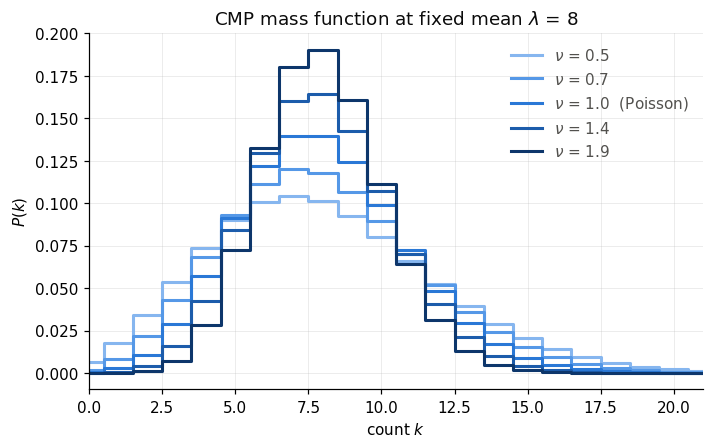

In [7]:
lam = 8.0
nus = [0.5, 0.7, 1.0, 1.4, 1.9]
k = np.arange(0, 22)

fig, ax = plt.subplots(figsize=(7.2, 4.2))
for nu, color in zip(nus, NU_RAMP):
    label = f"$\\nu$ = {nu}" + ("  (Poisson)" if nu == 1.0 else "")
    ax.step(k, d.pmf(k, lam, nu), where="mid", color=color, label=label)

ax.set_xlabel("count $k$")
ax.set_ylabel("$P(k)$")
ax.set_title(f"CMP mass function at fixed mean $\\lambda$ = {lam:g}", color=INK)
ax.legend(labelcolor=INK_SOFT)
ax.set_xlim(0, 21)
plt.show()

The same thing as a single number: the **variance-to-mean ratio**, which is 1 for a
Poisson distribution by definition. Below the analytic curve is overlaid with ratios
measured from actual draws, as a check that sampling matches theory.

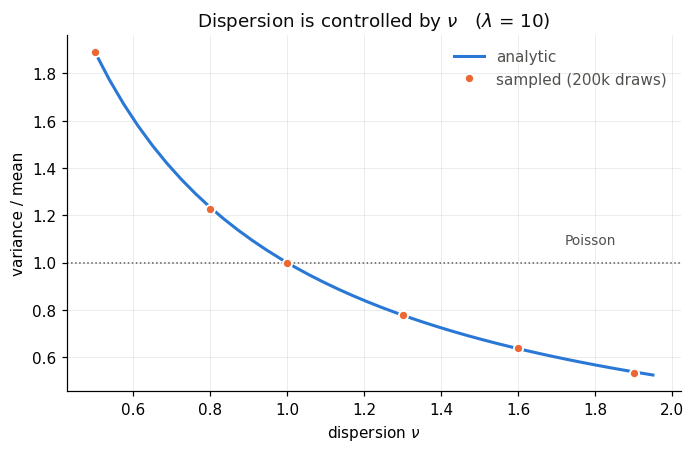

In [8]:
def analytic_moments(dist, lam, nu):
    """Mean and variance of the (truncated) CMP with the given mean parameter."""
    k = np.arange(dist.max_count(lam) + 1)
    p = dist.pmf(k, lam, nu)
    mean = (k * p).sum()
    var = (k**2 * p).sum() - mean**2
    return mean, var


lam = 10.0
nu_grid = np.linspace(0.5, 1.95, 40)
analytic = np.array([np.divide(*analytic_moments(d, lam, nu)[::-1]) for nu in nu_grid])

nu_pts = np.array([0.5, 0.8, 1.0, 1.3, 1.6, 1.9])
sampled = []
for nu in nu_pts:
    s = d.sample(np.full(200_000, lam), nu)
    sampled.append(s.var() / s.mean())

fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.plot(nu_grid, analytic, color=C_BLUE, label="analytic")
ax.plot(nu_pts, sampled, "o", color=C_ORANGE, label="sampled (200k draws)",
        markeredgecolor="white", markeredgewidth=1.2, zorder=3)
ax.axhline(1.0, color=INK_SOFT, lw=1, ls=":", zorder=0)
ax.annotate("Poisson", xy=(1.72, 1.0), xytext=(1.72, 1.08),
            color=INK_SOFT, fontsize=9)

ax.set_xlabel("dispersion $\\nu$")
ax.set_ylabel("variance / mean")
ax.set_title(f"Dispersion is controlled by $\\nu$   ($\\lambda$ = {lam:g})", color=INK)
ax.legend(labelcolor=INK_SOFT)
plt.show()

---
## 3. Draws match the mass function

A sanity check you can re-run with your own parameters: histogram 300k draws and
compare against `pmf`.

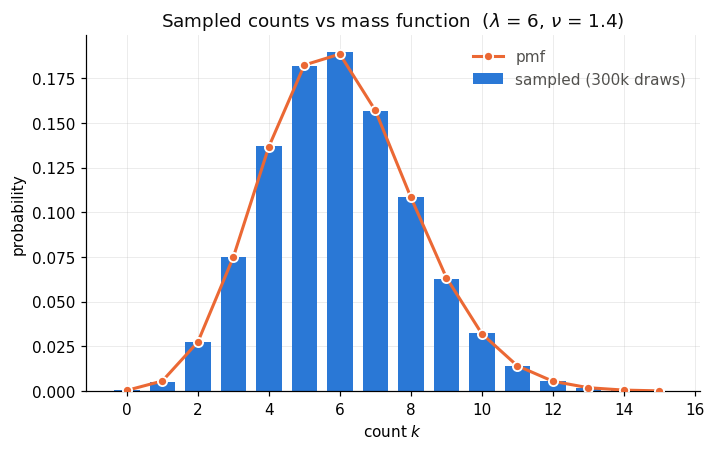

max |sampled - pmf| = 0.00096
mean  5.9960  (requested 6.0)


In [9]:
lam, nu = 6.0, 1.4
s = d.sample(np.full(300_000, lam), nu)

k = np.arange(0, 16)
observed = np.bincount(s, minlength=k.size)[:k.size] / s.size

fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.bar(k, observed, width=0.72, color=C_BLUE, label="sampled (300k draws)")
ax.plot(k, d.pmf(k, lam, nu), "o-", color=C_ORANGE, label="pmf",
        markeredgecolor="white", markeredgewidth=1.2, zorder=3)

ax.set_xlabel("count $k$")
ax.set_ylabel("probability")
ax.set_title(f"Sampled counts vs mass function  ($\\lambda$ = {lam:g}, $\\nu$ = {nu})",
             color=INK)
ax.legend(labelcolor=INK_SOFT)
plt.show()

print(f"max |sampled - pmf| = {np.abs(observed - d.pmf(k, lam, nu)).max():.5f}")
print(f"mean  {s.mean():.4f}  (requested {lam})")

---
## 4. Per-element $\nu$

`nu` can be a scalar shared by every draw, or **one value per draw** — which is how you
let the dispersion vary across the sample with any covariate you like. It just has to
be the same length as `lam`.

In [10]:
rng = np.random.default_rng(0)
n_sample = 400_000

x = rng.uniform(0.0, 1.0, n_sample)                  # some per-element covariate
# super-Poisson at low x, sub-Poisson at high x
nu_of_x = np.clip(0.55 + 1.35 * x, 0.5, 1.95)

# the mean is held fixed here, so the plot isolates the effect of nu alone
lam_fixed = np.full(n_sample, 12.0)
counts = d.sample(lam_fixed, nu_of_x)

print(f"nu spans {nu_of_x.min():.2f} .. {nu_of_x.max():.2f}")
print(f"overall mean count = {counts.mean():.3f}  (requested 12.0)")

nu spans 0.55 .. 1.90
overall mean count = 12.000  (requested 12.0)


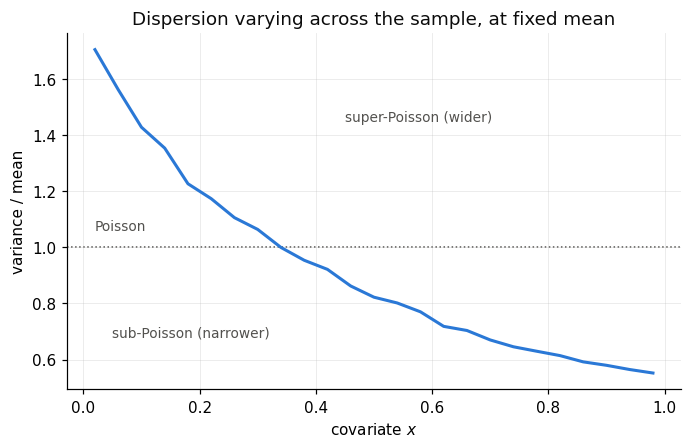

In [11]:
edges = np.linspace(0.0, 1.0, 26)
centres = 0.5 * (edges[:-1] + edges[1:])
idx = np.digitize(x, edges) - 1

ratio = np.array([counts[idx == j].var() / counts[idx == j].mean()
                  for j in range(centres.size)])

fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.plot(centres, ratio, color=C_BLUE)
ax.axhline(1.0, color=INK_SOFT, lw=1, ls=":", zorder=0)
ax.annotate("Poisson", xy=(0.02, 1.06), color=INK_SOFT, fontsize=9)
# label the two regimes in the empty corners, away from the curve
ax.annotate("super-Poisson (wider)", xy=(0.45, 1.45), color=INK_SOFT, fontsize=9)
ax.annotate("sub-Poisson (narrower)", xy=(0.05, 0.68), color=INK_SOFT, fontsize=9)

ax.set_xlabel("covariate $x$")
ax.set_ylabel("variance / mean")
ax.set_title("Dispersion varying across the sample, at fixed mean", color=INK)
plt.show()

High-$x$ elements come out sub-Poisson and low-$x$ ones super-Poisson, exactly as the
`nu_of_x` relation asks. In practice `lam` usually varies across the sample too — just
pass both as arrays of the same length.

---
## 5. Reproducibility

Sampling draws from a numpy `Generator`, so seeding works the ordinary way.

In [12]:
a = CMP(seed=7).sample(np.full(8, 4.0), 0.8)
b = CMP(seed=7).sample(np.full(8, 4.0), 0.8)
c = CMP(seed=8).sample(np.full(8, 4.0), 0.8)

print("same seed :", a, b, np.array_equal(a, b))
print("other seed:", c, np.array_equal(a, c))

same seed : [5 7 6 2 3 7 0 6] [5 7 6 2 3 7 0 6] True
other seed: [ 3 10  3  6  7  3  3  3] False


In [13]:
# share one Generator with the rest of your pipeline
rng = np.random.default_rng(2024)
shared = CMP(seed=rng)
shared.sample(np.full(5, 3.0), 1.1)

array([4, 2, 2, 4, 8])

---
## 6. Validity range

The mean-to-rate mapping is only valid for $0.5 \le \nu < 2$. Outside that window it
can return NaN and hand back all-zero counts, so an out-of-range $\nu$ **raises** by
default rather than silently corrupting your sample.

In [14]:
try:
    d.sample(np.full(5, 1.0), 0.3)
except ValueError as err:
    print("ValueError:", err)

ValueError: nu must satisfy 0.5 <= nu < 2.0; got 0.3. Outside that range the mean-to-rate mapping is not valid and can return NaN, giving meaningless counts. Pass on_invalid_nu='warn' or 'ignore' to override, or widen nu_range.


In [15]:
# the check is elementwise, so one bad entry in a per-draw array is caught
nu = np.full(5, 1.0)
nu[2] = 2.5
try:
    d.sample(np.full(5, 1.0), nu)
except ValueError as err:
    print("ValueError:", err)

ValueError: nu must satisfy 0.5 <= nu < 2.0; got 2.5. Outside that range the mean-to-rate mapping is not valid and can return NaN, giving meaningless counts. Pass on_invalid_nu='warn' or 'ignore' to override, or widen nu_range.


In [16]:
# relax it per instance if you know what you are doing
import warnings

lenient = CMP(seed=0, on_invalid_nu="warn")
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    out = lenient.sample(np.full(5, 1.0), 0.3)
print("warn   ->", out, f"({caught[0].category.__name__})")

print("ignore ->", CMP(seed=0, on_invalid_nu="ignore").sample(np.full(5, 1.0), 0.3))
print("wider  ->", CMP(seed=0, nu_range=(0.3, 3.0)).sample(np.full(5, 1.0), 0.4))

warn   -> [0 0 0 0 0] (RuntimeWarning)
ignore -> [0 0 0 0 0]
wider  -> [1 0 0 0 2]


Look at what those overridden calls actually return: **all zeros**, for a distribution
whose mean is supposed to be 1.0. At $\nu = 0.3$ the mean-to-rate mapping produces
NaN and every draw collapses to zero. That is precisely the silent failure the default
`on_invalid_nu="raise"` exists to prevent — if you do widen the range, check the
realised mean before trusting the output.

---
## 7. How accurately is the mean reproduced?

$\nu = 1$ is exact. Elsewhere the mean-to-rate inversion is approximate — the table
below is the **analytic** mean of the resulting distribution divided by the mean you
asked for, so these are real errors, not Monte Carlo noise.

In [17]:
lams = [0.05, 0.2, 0.5, 0.8, 1.0, 2.0, 5.0, 20.0, 100.0]
nus = [0.5, 0.6, 0.8, 1.0, 1.5, 1.9]

print("realised mean / requested lam")
print(f"{'lam':>6} " + "".join(f"  nu={n:<5}" for n in nus))
for lam in lams:
    row = "".join(f"  {analytic_moments(d, lam, nu)[0] / lam:7.3f}" for nu in nus)
    print(f"{lam:>6g} {row}")

realised mean / requested lam
   lam   nu=0.5    nu=0.6    nu=0.8    nu=1.0    nu=1.5    nu=1.9  
  0.05     1.000    1.000    1.000    1.000    1.000    1.000
   0.2     1.000    1.000    1.000    1.000    1.000    1.000
   0.5     0.974    0.993    0.999    1.000    0.999    0.999
   0.8     0.909    0.972    1.002    1.000    0.981    0.972
     1     0.949    0.996    1.011    1.000    0.972    0.962
     2     1.027    1.022    1.009    1.000    0.991    0.990
     5     1.010    1.006    1.002    1.000    0.999    0.999
    20     1.000    1.000    1.000    1.000    1.000    1.000
   100     1.000    1.000    1.000    1.000    1.000    1.000


The mapping is exact at $\nu = 1$ and for $\lambda \gtrsim 5$ or $\lambda \lesssim 0.2$.
The error concentrates in $0.5 < \lambda < 2$, where the small-mean series and the
large-mean asymptotic are blended, reaching **9% at $\lambda = 0.8,\ \nu = 0.5$**. If
much of your data sits in that corner with strongly non-Poisson $\nu$, calibrate
against this table rather than assuming the mean comes back exactly.

---
## 8. The rest of the API

In [18]:
print("rate     ", d.rate(5.0, 1.3))          # the CMP lambda behind a mean of 5
print("rate nu=1", d.rate(5.0, 1.0))          # exact: equals the mean
print("log Z    ", d.log_norm(4.1, 1.3))      # takes the rate, not the mean
print("max_count", d.max_count(5.0))          # where the CDF is truncated
print("pmf      ", np.round(d.pmf(np.arange(6), 2.0, 1.0), 5))

rate      8.347218480507252
rate nu=1 5.0
log Z     3.288178137444283
max_count 50
pmf       [0.13534 0.27067 0.27067 0.18045 0.09022 0.03609]


---
## 9. Performance

The kernels are numba-compiled and cached on disk, so the JIT cost is paid once per
machine. Two million draws take well under a second.

In [19]:
import time

big = np.random.default_rng(0).lognormal(0, 1, 2_000_000)
nu_big = np.full(big.size, 0.7)

d.sample(big[:10], 0.7)              # warm up the JIT
d.sample(big[:10], nu_big[:10])

for label, arg in [("scalar nu", 0.7), ("per-element nu", nu_big)]:
    times = []
    for _ in range(3):
        t0 = time.perf_counter()
        d.sample(big, arg)
        times.append(time.perf_counter() - t0)
    print(f"{label:14s}: {min(times):.3f} s for {big.size:,} draws")

scalar nu     : 0.698 s for 2,000,000 draws


per-element nu: 0.724 s for 2,000,000 draws
